### Import necessary packages & load data

In [1]:
from datasets import load_from_disk
import datasets 
from transformers import AutoTokenizer 
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
from data.CyberMetric import CyberMetric_evaluator
from openai import OpenAI 
import re
import evaluate
import numpy as np
import torch 
num_classes = 9
ds = load_from_disk("data/train.hf")
# convert to csv (necessary for k-fold cross validation
ds.to_csv("data/train_data.csv")

/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Creating CSV from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

63775

In [32]:
# random split just for debugging 
dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
train_val_split = dataset.train_test_split(test_size=0.1) 
train_dataset = train_val_split['train']
val_dataset = train_val_split['test']
print(len(dataset))

576


### Define functions

In [56]:
def submit_message_LLM(model, messages): 
    text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(device)
    
    generated_ids = model.generate(
        model_inputs.input_ids,
        max_new_tokens=512
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    
    return tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

def process_label(label): 
    output = [int(s) for s in re.findall(r'\d+', label)]
    output = str(output)
    output = output.replace(' ','')[1:-1]
    output = [int(num) for num in output.split(',')]
    return output 

clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])

def sigmoid(x):
   return 1/(1 + np.exp(-x))

def compute_metrics(eval_pred):
   predictions, labels = eval_pred
   predictions = sigmoid(predictions)
   predictions = (predictions > 0.5).astype(int).reshape(-1)
   return clf_metrics.compute(predictions=predictions, references=labels.astype(int).reshape(-1))

In [58]:
#predicted_label = submit_message_LLM(model2, query)
#print(predicted_label)
#output = process_label(predicted_label)
#print(output)
label1 = '0, 1, 2'
output = process_label(label1)
print(output)
label1 = '0'
output = process_label(label1)
print(output)

[0, 1, 2]
[0]


### Load model

In [3]:
# Load Qwen2-7B-Instruct model. 
from transformers import AutoModelForCausalLM, AutoTokenizer
device = "cuda" # the device to load the model onto

model2 = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct",
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

### Design prompt

In [6]:
import json
from tqdm import tqdm
import re 
KAs = {"0": "miscellaneous (this includes Computer Science, Business and Law, Communication and Networking, Information Technology, Cyberspace Practice, Pedagogy, and Intelligence)",
           "1": "data security", 
           "2": "software security",
           "3": "component security", 
           "4": "connection security", 
           "5": "system security", 
           "6": "human security", 
           "7": "organizational security",
           "8": "societal security"}

def label_KD_prompt(knowledge, KAs):
        """
        Formats a single question+answers into a list of message dictionaries for the pipeline.
        """
        options_str = ', '.join([f"{key}) {value}" for key, value in KAs.items()])
        instructions = (
            "You are a helpful AI assistant.\n"
            "Instructions:\n"
            "a. Carefully read the knowledge statement.\n"
            "b. Choose one or more of the following (0, 1, 2, 3, 4, 5, 6, 7, 8).\n"
            "c. Do NOT include any explanation or additional text in the response.\n"
           # "d. Always return the answer in this format: 'answer'. "
            #"For example, if the correct answers are 0 and 1, then return 0,1.\n\n"
        )
    
        messages = [
            {"role": "system", "content": instructions},
            {"role": "user", "content": 
            f"#Question: Classify the following statement {knowledge} into one or multiple of the following knowledge areas: \nOptions: {options_str}"}
        ]
        return messages

### Label all NIST 2017 KDs using LLM 

In [76]:
labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
for i, ele in enumerate(dataset): 
    KD = ele['Statement Description']
    KD = KD[13:]
    labels[i,:] = np.array([ele[str(p)] for p in range(9)])
    query = label_KD_prompt(KD, KAs)
    predicted_label = process_label(submit_message_LLM(model2, query))
    one_hot = np.array([1 if j in predicted_label else 0 for j in range(num_classes)])
    preds[i,:] = one_hot

output = compute_metrics((preds, labels))
print(output)

{'accuracy': 0.779320987654321, 'f1': 0.36725663716814155, 'precision': 0.2820730671197961, 'recall': 0.526148969889065}


In [77]:
print(output)

{'accuracy': 0.779320987654321, 'f1': 0.36725663716814155, 'precision': 0.2820730671197961, 'recall': 0.526148969889065}


In [100]:
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
#non_oh = [list(np.where(row==1)[0]) for row in labels]
#non_oh2 = [list(np.where(row==1)[0]) for row in preds]
print(multilabel_confusion_matrix(labels, preds))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

[[[133 238]
  [ 42 163]]

 [[371 152]
  [ 17  36]]

 [[495  55]
  [ 15  11]]

 [[530  30]
  [ 13   3]]

 [[473  23]
  [ 68  12]]

 [[339 185]
  [ 28  24]]

 [[541  30]
  [  5   0]]

 [[296 104]
  [ 95  81]]

 [[530  28]
  [ 16   2]]]


### Compare label distribution real dataset 

[4 7 8 2 5 8 0 3 4 5 4 7 5 7 2 4 4 5 4 7 0 0 0 1 1 1 6 7 5 0 7 0 1 7 7 5 7
 7 7 3 7 7 4 5 4 7 0 5 7 7 2 7 1 7 1 7 2 2 5 7 8 5 4 5 4 5 7 4 4 0 0 7 7 4
 6 3 4 4 1 4 4 4 7 1 8 5 2 0 5 7 4 7 7 7 2 5 3 5 7 4 7 2 2 2 2 7 7 7 2 5 7
 7 7 5 0 0 0 0 0 7 6 0 7 5 4 1 4 4 5 7 4 4 0 7 4 4 0 0 0 0 1 8 1 0 7 1 1 0
 1 8 3 7 1 0 5 1 1 1 1 0 0 7 0 2 2 0 0 0 1 0 7 3 7 7 7 2 2 3 8 8 8 7 0 1 4
 5 0 0 3 7 7 0 7 0 3 7 4 3 0 0 2 4 5 1 3 1 1 0 0 2 1 1 1 4 7 4 7 7 7 0 5 0
 1 1 4 5 0 4 7 8 3 6 0 7 5 7 0 7 7 0 0 0 0 4 8 7 0 4 0 5 4 7 8 5 0 7 0 4 0
 5 7 7 0 0 0 0 4 7 0 3 7 0 2 4 7 5 2 2 0 0 7 7 7 3 8 1 0 3 7 2 0 7 5 1 7 5
 0 0 7 1 0 7 5 7 3 0 7 7 7 5 7 5 5 4 4 7 0 1 1 1 0 0 0 8 8 7 0 0 7 0 0 0 5
 5 5 4 1 4 0 4 4 4 7 1 5 7 7 5 2 7 5 0 7 0 7 7 0 0 7 0 0 7 0 7 0 7 0 7 7 5
 0 0 0 7 2 0 7 4 0 0 0 0 7 0 1 7 0 5 7 0 5 0 7 0 7 0 0 0 0 5 5 7 0 4 0 7 0
 7 7 0 0 7 1 0 5 4 7 7 7 7 7 7 0 7 7 7 7 1 4 4 7 0 0 0 7 0 7 0 1 1 7 4 7 7
 1 0 7 5 4 5 7 0 0 4 4 4 4 1 0 1 1 7 0 0 0 0 0 0 0 0 0 0 0 0 7 0 7 7 7 4 4
 4 4 8 7 0 0 8 5 5 7 0 1 

(array([205.,  53.,  26.,  16.,   0.,  80.,  52.,   5., 176.,  18.]),
 array([0. , 0.8, 1.6, 2.4, 3.2, 4. , 4.8, 5.6, 6.4, 7.2, 8. ]),
 <BarContainer object of 10 artists>)

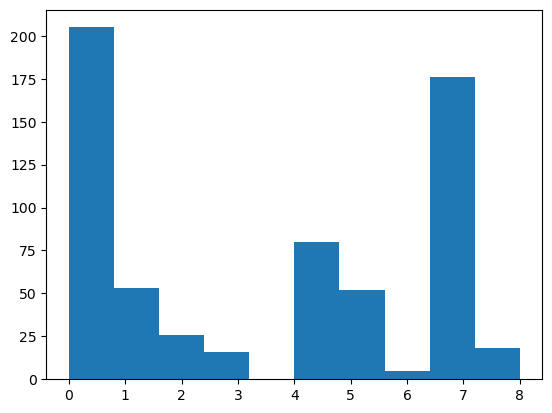

In [111]:
import matplotlib.pyplot as plt 
from collections import Counter 
non_oh = np.concatenate([list(np.where(row==1)[0]) for row in labels], axis=0)
print(non_oh)
print(len(non_oh))
counts, bins = np.histogram(non_oh)
plt.hist(bins[:-1], bins, weights=counts)